In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure TensorFlow to use GPU and limit memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        print("Using GPU 0 for training")
    except RuntimeError as e:
        print(e)

# Define paths for datasets
train_dataset_path = "/home/user/JAYANT/training_3"
test_dataset_path = "/home/user/JAYANT/testing_3"

# Image Data Generator for augmentation
trainGen = ImageDataGenerator(validation_split=0.15, vertical_flip=True, horizontal_flip=True, rotation_range=0.2)
testGen = ImageDataGenerator()

# Train, validation, and test data loaders
trainGenerator = trainGen.flow_from_directory(train_dataset_path, subset="training", target_size=(224, 224), batch_size=128)
validationGenerator = trainGen.flow_from_directory(train_dataset_path, subset="validation", target_size=(224, 224), batch_size=128)
testGenerator = testGen.flow_from_directory(test_dataset_path, target_size=(224, 224), shuffle=False)

# Define ResNet50 model
base_model = ResNet50(include_top=False, weights="imagenet")
for layer in base_model.layers[:140]:
    layer.trainable = False

model = keras.Sequential()
model.add(layers.Input(shape=(224, 224, 3)))  # Correct input shape: 3 channels (RGB)
model.add(layers.Lambda(keras.applications.resnet50.preprocess_input))
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(2, activation="softmax"))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train the model
history = model.fit(
    trainGenerator,
    validation_data=validationGenerator,
    epochs=10,
    steps_per_epoch=len(trainGenerator),
    validation_steps=len(validationGenerator)
)

# Save the model
model.save("/home/user/JAYANT/saved_models/drosophilaa_resnet50_classifier.keras")




2024-09-25 10:23:08.296393: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-25 10:23:08.313197: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-25 10:23:08.318347: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-25 10:23:08.330209: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-25 10:23:09.082825: W tensorflow/compiler/tf2

Using GPU 0 for training
Found 10988 images belonging to 2 classes.
Found 1938 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


2024-09-25 10:23:10.876734: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15968 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:c1:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

2024-09-25 11:08:48.089277: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2024-09-25 11:09:01.679231: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 2 of 8
2024-09-25 11:09:21.392918: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5 of 8
2024-09-25 11:09:34.595356: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 7 of 8


 1/86 ━━━━━━━━━━━━━━━━━━━━ 1:15:22 53s/step - accuracy: 0.9531 - loss: 0.0944

2024-09-25 11:09:41.191045: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


86/86 ━━━━━━━━━━━━━━━━━━━━ 673s 7s/step - accuracy: 0.9613 - loss: 0.0907 - val_accuracy: 0.8473 - val_loss: 0.4930
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 165us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00


FileNotFoundError: [Errno 2] No such file or directory: '/home/user/JAYANT/saved_models/drosophilaa_resnet50_classifier.keras'

In [2]:
import os

# Define the path where the model will be saved
save_model_directory = "/home/user/JAYANT/saved_models"
save_model_path = os.path.join(save_model_directory, "drosophilaa_resnet50_classifier.keras")

# Check if the directory exists, and create it if it doesn't
if not os.path.exists(save_model_directory):
    os.makedirs(save_model_directory)

# Save the model
model.save(save_model_path)

print(f"Model saved to {save_model_path}")


Model saved to /home/user/JAYANT/saved_models/drosophilaa_resnet50_classifier.keras


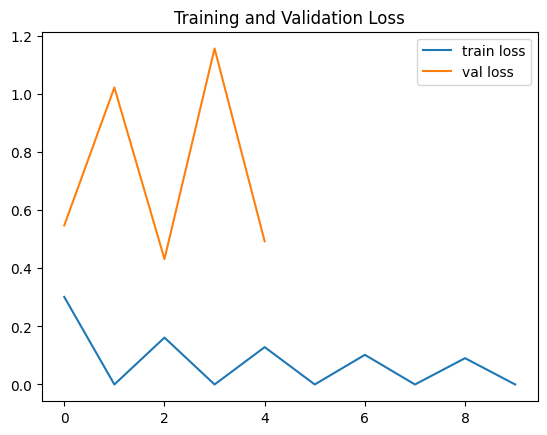

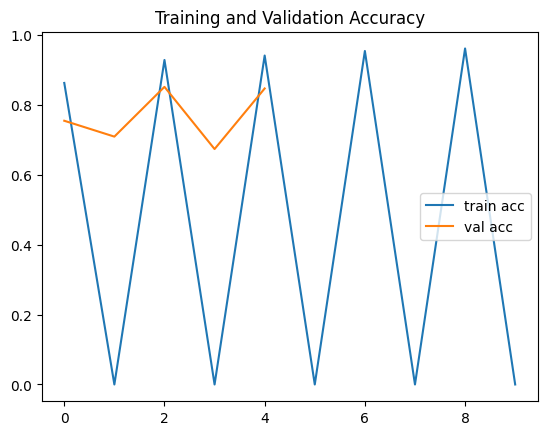

2024-09-25 11:25:00.081993: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1701', 196 bytes spill stores, 196 bytes spill loads



3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step 

2024-09-25 11:25:06.722676: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1701', 8 bytes spill stores, 8 bytes spill loads



4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
Test Accuracy: 91.00%
Classification Report:
               precision    recall  f1-score   support

      Female       0.90      0.92      0.91        50
        Male       0.92      0.90      0.91        50

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



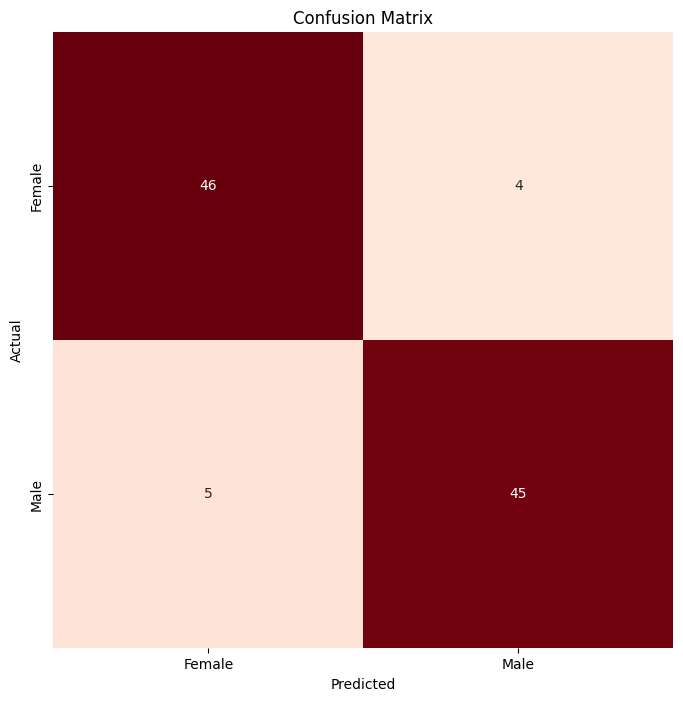

In [3]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Prediction on test data
CLASS_NAMES = list(trainGenerator.class_indices.keys())
predictions = np.argmax(model.predict(testGenerator), axis=1)

# Accuracy and classification report
acc = accuracy_score(testGenerator.labels, predictions)
cm = tf.math.confusion_matrix(testGenerator.labels, predictions)
clr = classification_report(testGenerator.labels, predictions, target_names=CLASS_NAMES)

print(f"Test Accuracy: {acc * 100:.2f}%")
print("Classification Report:\n", clr)




In [4]:
from tensorflow.keras.models import load_model

 #Assuming your ResNet-50 model is stored in the 'model' variable
model.save("/home/user/JAYANT/saved_models/drosophilaa_resnet50_classifier.keras")
